<a href="https://colab.research.google.com/github/routparam12/Python_qns/blob/main/Opinionedge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib

In [21]:
df = pd.read_csv('/content/panelists.csv')
df.columns

/tmp/ipykernel_11494/4108233907.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/panelists.csv')


Index(['panelistId', 'panelistGuid', 'firstName', 'lastName', 'mobile',
       'panelistName', 'gender', 'dob', 'age', 'zipCode', 'email',
       'passwordSalt', 'password', 'subscriptionId', 'panelId', 'address',
       'city', 'state', 'countryId', 'languageId', 'isEmailVerified',
       'emailVerifyDate', 'lastForgotPassDate', 'unsubscribe',
       'unsubscribeDate', 'joinIp', 'joinDate', 'fcmToken', 'sourceId',
       'lastLoginIp', 'lastLoginDate', 'referralCode', 'isSampleAllow',
       'isActive', 'createdId', 'updatedId', 'panelistImage', 'currency',
       'levelId', 'createdAt', 'updatedAt', 'deleteReason', 'device',
       'visitorId', 'userType', 'emailScore', 'prevEmail', 'categoryType'],
      dtype='object')

/tmp/ipykernel_11494/3131985432.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['joinMonth'] = df['joinDate'].dt.to_period('M').dt.to_timestamp()


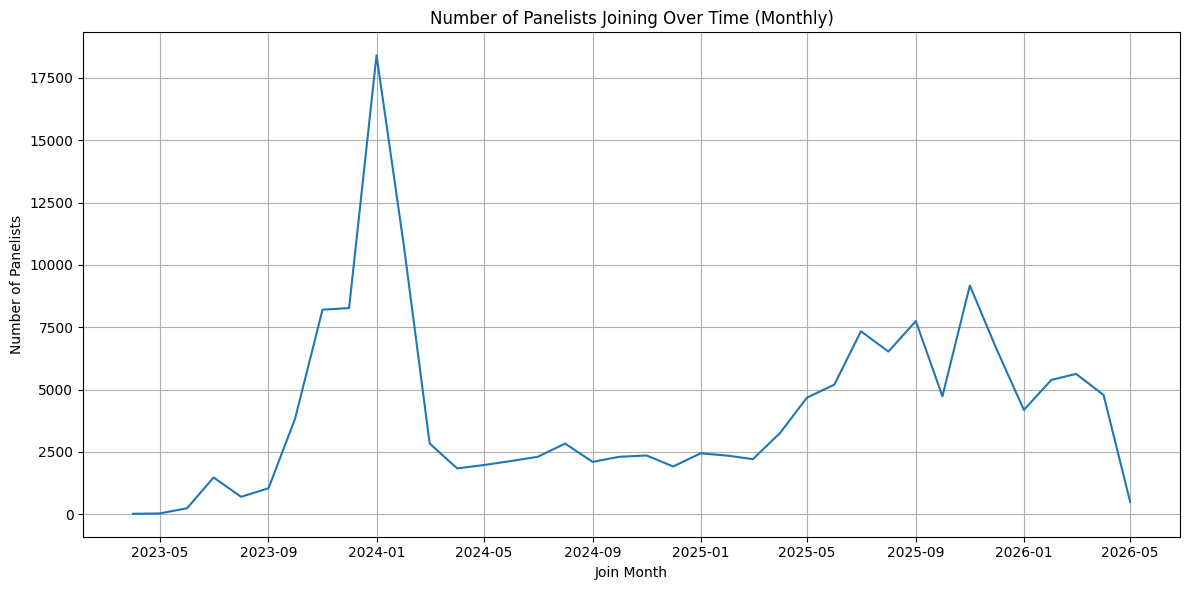

In [19]:
import matplotlib.pyplot as plt

# Convert 'joinDate' to datetime objects, handling potential errors
df['joinDate'] = pd.to_datetime(df['joinDate'], errors='coerce')

# Drop rows where 'joinDate' couldn't be parsed (if any)
df.dropna(subset=['joinDate'], inplace=True)

# Create a new column for the first day of the month
df['joinMonth'] = df['joinDate'].dt.to_period('M').dt.to_timestamp()

# Group by 'joinMonth' and count 'panelistId'
panelists_by_month = df.groupby('joinMonth')['panelistId'].count().reset_index()
panelists_by_month.columns = ['Join Month', 'Number of Panelists']

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(panelists_by_month['Join Month'], panelists_by_month['Number of Panelists'])
plt.xlabel('Join Month')
plt.ylabel('Number of Panelists')
plt.title('Number of Panelists Joining Over Time (Monthly)')
plt.grid(True)
plt.tight_layout()
plt.show()

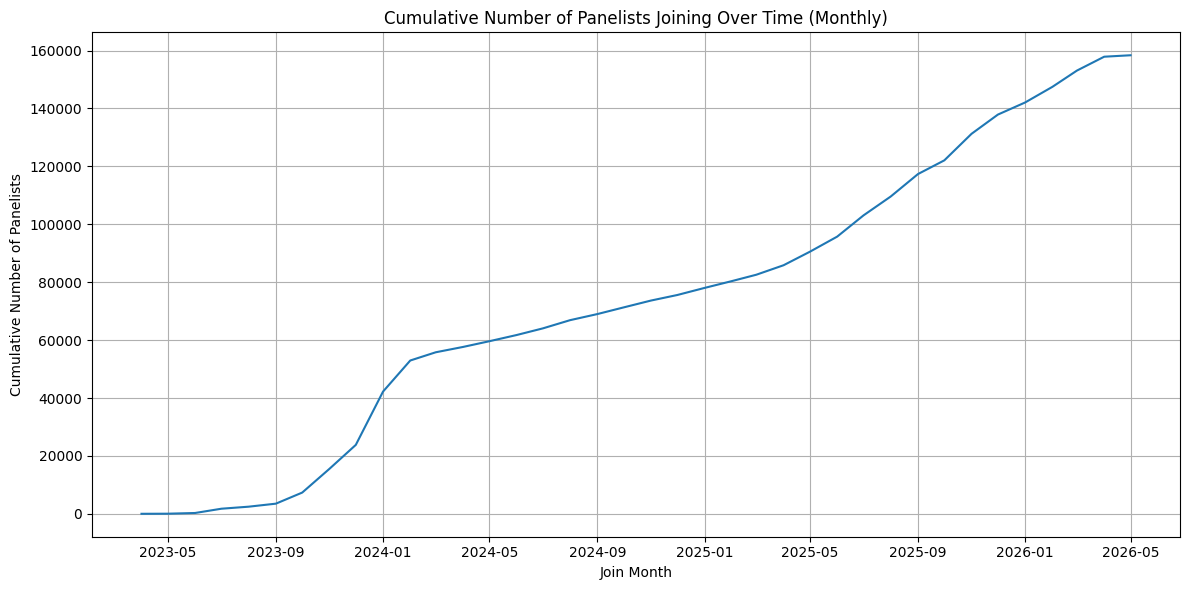

In [20]:
# Calculate the cumulative sum of panelists
panelists_by_month['Cumulative Panelists'] = panelists_by_month['Number of Panelists'].cumsum()

# Plot the cumulative results
plt.figure(figsize=(12, 6))
plt.plot(panelists_by_month['Join Month'], panelists_by_month['Cumulative Panelists'])
plt.xlabel('Join Month')
plt.ylabel('Cumulative Number of Panelists')
plt.title('Cumulative Number of Panelists Joining Over Time (Monthly)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
display(df[['panelistId', 'firstName','lastName','age','zipCode','joinDate','joinIp','email','device']].head())

,panelistId,firstName,lastName,age,zipCode,joinDate,joinIp,email,device
0,91989,Jakub,Olszewski,19,17-132,2025-05-30 19:30:03.367 +0530,130.180.196.18,1748613780618_gamekrzywy@gmail.com,2.0
1,99712,Ronald,Martin,46,45133,2025-07-10 21:50:54.353 +0530,172.58.55.23,heskamran4@gmail.com,3.0
2,6827,Alexis,Wynn,14,75141,2023-10-25 18:02:31.455 +0530,70.142.206.24,alexiswynn84@gmail.com,3.0
3,11096,Joanne,Ferins,51,FY52BY,2023-11-16 21:46:07.091 +0530,82.132.216.103,jojoferins@gmail.com,2.0
4,76703,Nathan,Lloyd,19,SE182DE,2025-01-06 08:18:57.401 +0530,86.16.230.181,ngamemasterl@gmail.com,3.0


In [27]:
# Filter rows where emails start with a number and select the desired columns
# Using regex '^\d' to match emails starting with a digit
filtered_panelists = df[df['email'].astype(str).str.match(r'^\d')][['panelistId', 'firstName', 'lastName', 'age', 'zipCode', 'joinIp', 'device', 'email','joinDate']]

# Display the top 100 such entries
if not filtered_panelists.empty:
    print(f"Found {len(filtered_panelists)} panelists with emails starting with a number. Displaying top 100 with additional details:")
    display(filtered_panelists.head(100))
else:
    print("No panelists with emails starting with a number found.")

Found 5288 panelists with emails starting with a number. Displaying top 100 with additional details:


,panelistId,firstName,lastName,age,zipCode,joinIp,device,email,joinDate
0,91989,Jakub,Olszewski,19,17-132,130.180.196.18,2.0,1748613780618_gamekrzywy@gmail.com,2025-05-30 19:30:03.367 +0530
8,94099,Alex,Martens,21,T1Z0M7,104.224.122.21,3.0,1234zamiz@gmail.com,2025-06-11 15:54:52.191 +0530
20,12225,sierra,worsham,26,45238,74.215.226.252,3.0,1700511497124_sierraworsham@gmail.com,2023-11-21 00:46:17.914 +0530
22,26674,Aayush,Yadav,21,226021,49.36.214.126,3.0,1706462159546_yaayush320@gmail.com,2024-01-07 18:10:55.536 +0530
76,39315,Mattias,Zdrinca,22,34100,93.33.144.68,1.0,1706374465309_onepuncmanito@gmail.com,2024-01-27 22:18:10.258 +0530
...,...,...,...,...,...,...,...,...,...
4410,58314,Kellie,Gallagher,42,20011,174.218.224.32,3.0,1728934659126_kelliegallagher82@outlook.com,2024-05-04 01:14:50.948 +0530
4431,13134,Jeff,Vegter,26,T1K7B7,70.65.72.239,3.0,237jeff@gmail.com,2023-11-23 06:45:45.980 +0530
4468,8881,Jaclin,Douglas,32,60089,69.136.176.137,3.0,1700292828324_jaclindouglas@yahoo.com,2023-11-05 08:46:08.179 +0530
4516,6692,Joshua,Boatman,34,51031,67.22.196.31,1.0,1698175096437_joshuaboatman62@gmail.com,2023-10-25 00:26:04.443 +0530


In [30]:
# Install fuzzywuzzy and its dependency
%pip install fuzzywuzzy python-Levenshtein

# Import the necessary libraries for fuzzy matching
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.6 MB/s eta 0:00:00


### Fuzzy Logic for Email Similarity

Fuzzy string matching, often known as fuzzy logic, helps identify strings that are approximately similar rather than exactly identical. This is particularly useful for detecting typos, variations, or near-duplicates in text data like email addresses.

Here, we'll use `fuzzywuzzy` to find emails that are 'similar' to a chosen reference email within our dataset, first for those starting with numbers, then for those starting with letters. We'll set a similarity threshold to determine what counts as 'similar'.

### 1. Fuzzy Check for Emails Starting with Numbers

In [31]:
# Let's use the 'filtered_panelists' DataFrame we created earlier for emails starting with numbers
numeric_emails = filtered_panelists['email'].tolist()

# Choose a reference email from this list to find similar ones
# We'll pick the first one for demonstration, but you can choose any.
if numeric_emails:
    reference_email_numeric = numeric_emails[0]
    print(f"Reference email (numeric-starting): {reference_email_numeric}")

    # Find emails in the list that are similar to the reference email
    # process.extractBests returns a list of (string, score, index) tuples
    # We'll look for scores above a certain threshold (e.g., 85)
    similar_numeric_emails = process.extractBests(
        reference_email_numeric,
        numeric_emails,
        scorer=fuzz.ratio,
        score_cutoff=85
    )

    print(f"\nEmails similar to '{reference_email_numeric}' (score >= 85):\n")
    if similar_numeric_emails:
        # Extract just the similar emails and then filter the original DataFrame
        similar_email_strings = [item[0] for item in similar_numeric_emails]
        display(filtered_panelists[filtered_panelists['email'].isin(similar_email_strings)])
    else:
        print("No similar emails found above the threshold for numeric-starting emails.")
else:
    print("No numeric-starting emails found to perform fuzzy checking.")

Reference email (numeric-starting): 1748613780618_gamekrzywy@gmail.com

Emails similar to '1748613780618_gamekrzywy@gmail.com' (score >= 85):



,panelistId,firstName,lastName,age,zipCode,joinIp,device,email,joinDate
0,91989,Jakub,Olszewski,19,17-132,130.180.196.18,2.0,1748613780618_gamekrzywy@gmail.com,2025-05-30 19:30:03.367 +0530


### 2. Fuzzy Check for Emails Starting with Letters

In [39]:
def get_similar_panelists(input_email, score_threshold=85):
    """
    Searches for similar emails in the dataset and returns panelist details including the match score.
    """
    # Get all unique emails from the dataset
    all_emails = df['email'].astype(str).unique().tolist()

    # Use fuzzy matching to find best matches
    # extractBests returns list of (string, score)
    matches = process.extractBests(input_email, all_emails, scorer=fuzz.ratio, score_cutoff=score_threshold)

    if not matches:
        return pd.DataFrame()

    # Create a mapping of email to score
    score_map = {match[0]: match[1] for match in matches}
    similar_email_list = list(score_map.keys())

    # Filter the main dataframe
    result = df[df['email'].isin(similar_email_list)][[
        'email', 'panelistId', 'age', 'zipCode', 'joinIp', 'joinDate', 'device'
    ]].copy()

    # Add the match score column next to email
    result['match_score'] = result['email'].map(score_map)

    # Reorder columns to put match_score next to email
    cols = ['email', 'match_score', 'panelistId', 'age', 'zipCode', 'joinIp', 'joinDate', 'device']
    return result[cols]

# --- Example Usage ---
get_similar_panelists('ananikimpeoples58@outlook.com')

,email,match_score,panelistId,age,zipCode,joinIp,joinDate,device
11470,ananikimpeoples58@outlook.com,100,122551,42,11216,174.195.83.26,2025-10-21 20:08:51.714 +0530,3.0
29294,ananikimpeoples@outlook.com,96,80445,42,11216,174.244.147.167,2025-02-17 00:02:25.730 +0530,3.0
46379,ananikimpeoples826@outlook.com,95,110328,42,11216,174.195.82.154,2025-08-23 21:44:23.862 +0530,3.0
89470,ananikimpeoples159@outlook.com,95,110555,42,11216,174.242.32.85,2025-08-25 10:35:12.965 +0530,3.0
133509,ananikimpeoples555@outlook.com,95,144499,42,11216,174.243.210.65,2026-02-02 15:54:58.431 +0530,3.0


In [32]:
# First, identify emails that start with letters
letter_starting_panelists = df[~df['email'].astype(str).str.match(r'^\d')].copy()
letter_emails = letter_starting_panelists['email'].tolist()

# Choose a reference email from this list
if letter_emails:
    reference_email_letter = letter_emails[0]
    print(f"Reference email (letter-starting): {reference_email_letter}")

    # Find emails in the list that are similar to the reference email
    similar_letter_emails = process.extractBests(
        reference_email_letter,
        letter_emails,
        scorer=fuzz.ratio,
        score_cutoff=85
    )

    print(f"\nEmails similar to '{reference_email_letter}' (score >= 85):\n")
    if similar_letter_emails:
        similar_email_strings = [item[0] for item in similar_letter_emails]
        display(letter_starting_panelists[letter_starting_panelists['email'].isin(similar_email_strings)])
    else:
        print("No similar emails found above the threshold for letter-starting emails.")
else:
    print("No letter-starting emails found to perform fuzzy checking.")

Reference email (letter-starting): heskamran4@gmail.com

Emails similar to 'heskamran4@gmail.com' (score >= 85):



,panelistId,panelistGuid,firstName,lastName,mobile,panelistName,gender,dob,age,zipCode,...,levelId,createdAt,updatedAt,deleteReason,device,visitorId,userType,emailScore,prevEmail,categoryType
1,99712,303c3876-f165-4272-beb3-43b6736b433c,Ronald,Martin,NaN,NaN,Male,2/1/1979,46,45133,...,1,2025-07-10 21:50:54.355 +0530,2025-08-01 19:59:33.583 +0530,NaN,3.0,2tdw7Aw8q60nNmr3F4yT,2.0,55.0,NaN,2


### API Function for Email Similarity Search

This function takes an input email and returns the details of panelists with similar email addresses from the dataset.

You can now call `get_similar_panelists('any_email@example.com')` to retrieve the data.

## Visualizing Panelist Joins with Plotly

In [28]:
import plotly.express as px

# Plot the Number of Panelists Joining Over Time (Monthly) using Plotly
fig_monthly = px.line(
    panelists_by_month,
    x='Join Month',
    y='Number of Panelists',
    title='Number of Panelists Joining Over Time (Monthly) (Plotly)'
)
fig_monthly.update_layout(xaxis_title='Join Month', yaxis_title='Number of Panelists')
fig_monthly.show()

In [29]:
import plotly.express as px

# Plot the Cumulative Number of Panelists Joining Over Time (Monthly) using Plotly
fig_cumulative = px.line(
    panelists_by_month,
    x='Join Month',
    y='Cumulative Panelists',
    title='Cumulative Number of Panelists Joining Over Time (Monthly) (Plotly)'
)
fig_cumulative.update_layout(xaxis_title='Join Month', yaxis_title='Cumulative Number of Panelists')
fig_cumulative.show()